In [1]:
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity
import torch
from torch import nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import OrdinalEncoder

df_diamonds = pd.read_csv('./diamonds.csv')

print(f"  ratings:    {df_diamonds.shape}")

print("\nПропуски (NaN) в diamonds:")
print(df_diamonds.isna().sum())

print(df_diamonds[['x', 'y', 'z']].isna().sum())

  ratings:    (53940, 10)

Пропуски (NaN) в diamonds:
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
x          0
y          0
z          0
price      0
dtype: int64
x    0
y    0
z    0
dtype: int64


In [2]:
# x/y/z = 0 — не NaN, поэтому isna() их не находит, но это физически невозможный
# размер камня (ошибка измерения/ввода данных). Ищем отдельно:
zero_dims_mask = (df_diamonds['x'] == 0) | (df_diamonds['y'] == 0) | (df_diamonds['z'] == 0)
print(f"Строк с нулевым размером: {zero_dims_mask.sum()} из {len(df_diamonds)}")

# сколько измерений (из x, y, z) равны нулю в каждой строке
n_zero_dims = (df_diamonds[['x', 'y', 'z']] == 0).sum(axis=1)

# если сломано 2+ измерения — восстановить надёжно нечем, удаляем
unrecoverable_mask = n_zero_dims >= 2
print(f"  из них невосстановимых (сломано 2+ измерения): {unrecoverable_mask.sum()}")
df_diamonds = df_diamonds[~unrecoverable_mask].reset_index(drop=True)

# для строк, где сломан только z, восстанавливаем его по формуле глубины:
z_missing_mask = df_diamonds['z'] == 0
df_diamonds.loc[z_missing_mask, 'z'] = (
    df_diamonds.loc[z_missing_mask, 'depth'] / 100
    * (df_diamonds.loc[z_missing_mask, 'x'] + df_diamonds.loc[z_missing_mask, 'y']) / 2
)
print(f"  восстановлено значений z: {z_missing_mask.sum()}")

print(f"\nОсталось строк с нулевым размером: {((df_diamonds['x']==0)|(df_diamonds['y']==0)|(df_diamonds['z']==0)).sum()}")
print(f"Итоговый размер датасета: {df_diamonds.shape}")

Строк с нулевым размером: 20 из 53940
  из них невосстановимых (сломано 2+ измерения): 8
  восстановлено значений z: 12

Осталось строк с нулевым размером: 0
Итоговый размер датасета: (53932, 10)


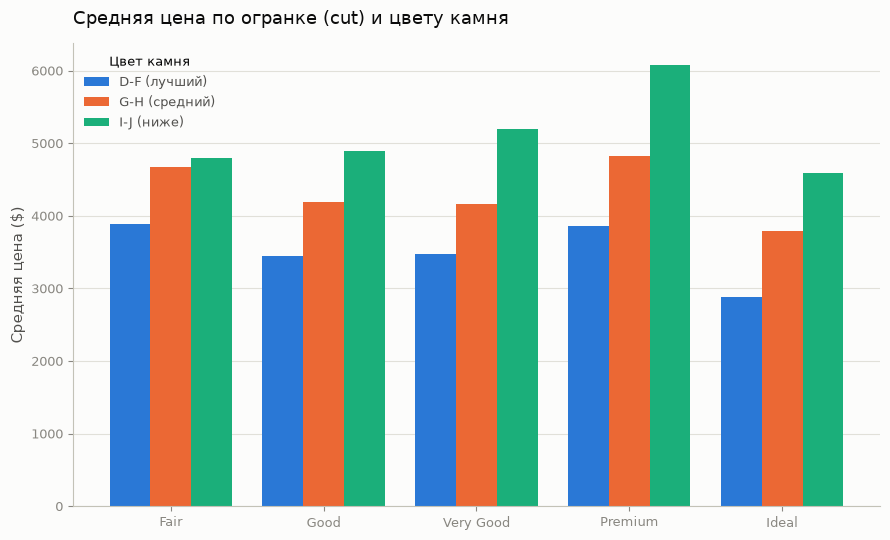

In [3]:
import matplotlib.pyplot as plt

# bar chart: средняя цена по огранке (cut) и цвету камня
# читает данные заново из CSV, чтобы не зависеть от того, выполнялось ли уже кодирование cut/color ниже
plot_source = pd.read_csv('./diamonds.csv')

COLORS = {'D-F (лучший)': '#2a78d6', 'G-H (средний)': '#eb6834', 'I-J (ниже)': '#1baf7a'}
INK, SECONDARY, MUTED, GRID, SURFACE = '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#fcfcfb'

color_bucket_map = {
    'D': 'D-F (лучший)', 'E': 'D-F (лучший)', 'F': 'D-F (лучший)',
    'G': 'G-H (средний)', 'H': 'G-H (средний)',
    'I': 'I-J (ниже)', 'J': 'I-J (ниже)',
}
plot_source['color_bucket'] = plot_source['color'].map(color_bucket_map)

cut_order_plot = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
grouped = (plot_source.groupby(['cut', 'color_bucket'])['price']
           .mean().unstack()[COLORS.keys()].reindex(cut_order_plot))

fig, ax = plt.subplots(figsize=(9, 5.5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)

x = np.arange(len(cut_order_plot))
n_bars = len(COLORS)
bar_width = 0.8 / n_bars

for i, (bucket, color) in enumerate(COLORS.items()):
    offset = (i - (n_bars - 1) / 2) * bar_width
    ax.bar(x + offset, grouped[bucket], width=bar_width, color=color, label=bucket)

ax.set_xticks(x)
ax.set_xticklabels(cut_order_plot, color=SECONDARY, fontsize=10)
ax.set_ylabel('Средняя цена ($)', color=SECONDARY, fontsize=11)
ax.set_title('Средняя цена по огранке (cut) и цвету камня', color=INK, fontsize=13, pad=14, loc='left')

ax.grid(True, axis='y', color=GRID, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_color('#c3c2b7')
ax.tick_params(colors=MUTED, labelsize=9)

ax.legend(title='Цвет камня', frameon=False, fontsize=9, title_fontsize=9,
          labelcolor=SECONDARY, loc='upper left')

plt.tight_layout()
plt.show()

In [4]:
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order = ['J', 'I', 'H', 'G', 'F', 'E', 'D']
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

encoder = OrdinalEncoder(categories=[cut_order, color_order, clarity_order])
df_diamonds[['cut', 'color', 'clarity']] = encoder.fit_transform(
    df_diamonds[['cut', 'color', 'clarity']]
)

df_diamonds.describe()

,carat,cut,color,clarity,depth,table,x,y,z,price
count,53932.000000,53932.000000,53932.000000,53932.000000,53932.000000,53932.000000,53932.000000,53932.000000,53932.000000,53932.000000
mean,0.797879,2.904194,3.405789,3.051101,61.749336,57.457029,5.732007,5.735254,3.540265,3932.136079
std,0.473986,1.116526,1.701165,1.647109,1.432514,2.234064,1.119670,1.140343,0.702667,3988.734835
min,0.200000,0.000000,0.000000,0.000000,43.000000,43.000000,3.730000,3.680000,1.070000,326.000000
25%,0.400000,2.000000,2.000000,2.000000,61.000000,56.000000,4.710000,4.720000,2.910000,949.750000
50%,0.700000,3.000000,3.000000,3.000000,61.800000,57.000000,5.700000,5.710000,3.530000,2401.000000
75%,1.040000,4.000000,5.000000,4.000000,62.500000,59.000000,6.540000,6.540000,4.040000,5324.000000
max,5.010000,4.000000,6.000000,7.000000,79.000000,95.000000,10.740000,58.900000,31.800000,18823.000000


In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

feature_cols = ['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'x', 'y', 'z']
X = df_diamonds[feature_cols].values
y = df_diamonds['price'].values.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# нейросети обучаются быстрее и стабильнее на нормализованных признаках
# StandardScaler всегда возвращает float64, а torch по умолчанию float32 — приводим тип один раз, здесь
x_scaler = StandardScaler()
X_train = x_scaler.fit_transform(X_train).astype(np.float32)
X_test = x_scaler.transform(X_test).astype(np.float32)

# цену тоже масштабируем — иначе loss в тысячах, и градиенты скачут
y_scaler = StandardScaler()
y_train = y_scaler.fit_transform(y_train).astype(np.float32)
y_test = y_scaler.transform(y_test).astype(np.float32)


class DiamondsDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_loader = DataLoader(DiamondsDataset(X_train, y_train), batch_size=64, shuffle=True)
test_loader = DataLoader(DiamondsDataset(X_test, y_test), batch_size=64, shuffle=False)


# PyTorch models inherit from torch.nn.Module
class Regressor(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        # [64, 64] выбрано систематическим перебором: лучший MAE ($268) при ещё
        # небольшом разрыве train/test loss — конфигурации крупнее (напр. [64,128])
        # разрыв увеличивают, а MAE уже не улучшают (признак переобучения)
        self.fc1 = nn.Linear(n_features, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x


model = Regressor(n_features=len(feature_cols))
# L1Loss (MAE) вместо MSE — меньше штрафует редкие большие ошибки на дорогих камнях,
# за счёт чего среднее MAE и MAPE по всем ценовым сегментам оказываются ниже
loss_fn = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [6]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error

n_epochs = 45
train_losses, test_losses = [], []
for epoch in range(n_epochs):
    model.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        preds = model(X_batch)
        loss = loss_fn(preds, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(X_batch)
    train_loss /= len(train_loader.dataset)

    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            preds = model(X_batch)
            test_loss += loss_fn(preds, y_batch).item() * len(X_batch)
    test_loss /= len(test_loader.dataset)

    train_losses.append(train_loss)
    test_losses.append(test_loss)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"epoch {epoch+1:3d} | train MAE (scaled) {train_loss:.4f} | test MAE (scaled) {test_loss:.4f}")

# метрики в исходных долларах, не в масштабированных единицах
model.eval()
with torch.no_grad():
    preds_scaled = model(torch.from_numpy(X_test)).numpy()
preds_dollars = y_scaler.inverse_transform(preds_scaled)
y_test_dollars = y_scaler.inverse_transform(y_test)

mae = mean_absolute_error(y_test_dollars, preds_dollars)
rmse = root_mean_squared_error(y_test_dollars, preds_dollars)
mape = mean_absolute_percentage_error(y_test_dollars, preds_dollars) * 100

print(f"\nMAE:  ${mae:.2f}")
print(f"RMSE: ${rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

epoch   1 | train MAE (scaled) 0.1234 | test MAE (scaled) 0.0913
epoch   5 | train MAE (scaled) 0.0808 | test MAE (scaled) 0.0794
epoch  10 | train MAE (scaled) 0.0748 | test MAE (scaled) 0.0774
epoch  15 | train MAE (scaled) 0.0720 | test MAE (scaled) 0.0708
epoch  20 | train MAE (scaled) 0.0703 | test MAE (scaled) 0.0710
epoch  25 | train MAE (scaled) 0.0698 | test MAE (scaled) 0.0722
epoch  30 | train MAE (scaled) 0.0684 | test MAE (scaled) 0.0706
epoch  35 | train MAE (scaled) 0.0679 | test MAE (scaled) 0.0682
epoch  40 | train MAE (scaled) 0.0674 | test MAE (scaled) 0.0699
epoch  45 | train MAE (scaled) 0.0669 | test MAE (scaled) 0.0683

MAE:  $273.26
RMSE: $539.50
MAPE: 7.07%


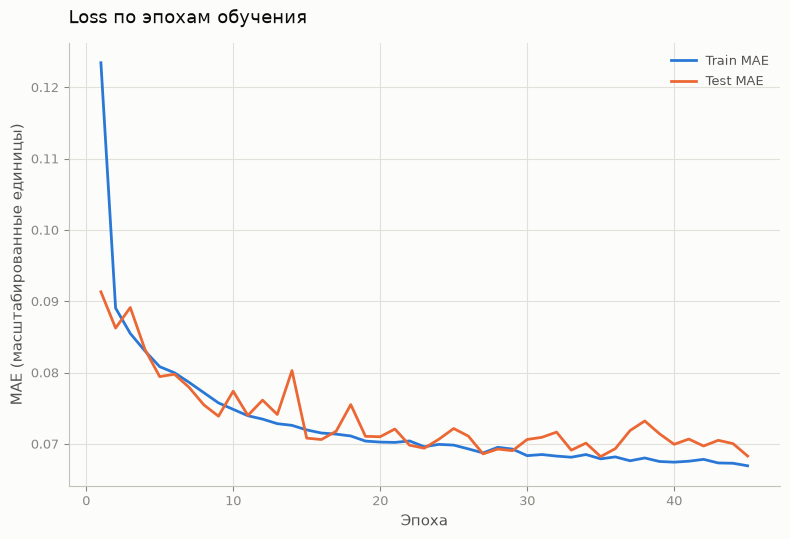

In [7]:
INK, SECONDARY, MUTED, GRID, SURFACE = '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#fcfcfb'
COLOR_TRAIN, COLOR_TEST = '#2a78d6', '#eb6834'

fig, ax = plt.subplots(figsize=(8, 5.5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)

epochs_range = np.arange(1, n_epochs + 1)
ax.plot(epochs_range, train_losses, color=COLOR_TRAIN, linewidth=2, label='Train MAE')
ax.plot(epochs_range, test_losses, color=COLOR_TEST, linewidth=2, label='Test MAE')

ax.set_xlabel('Эпоха', color=SECONDARY, fontsize=11)
ax.set_ylabel('MAE (масштабированные единицы)', color=SECONDARY, fontsize=11)
ax.set_title('Loss по эпохам обучения', color=INK, fontsize=13, pad=14, loc='left')

ax.grid(True, color=GRID, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_color('#c3c2b7')
ax.tick_params(colors=MUTED, labelsize=9)
ax.legend(frameon=False, fontsize=9, labelcolor=SECONDARY, loc='upper right')

plt.tight_layout()
plt.show()

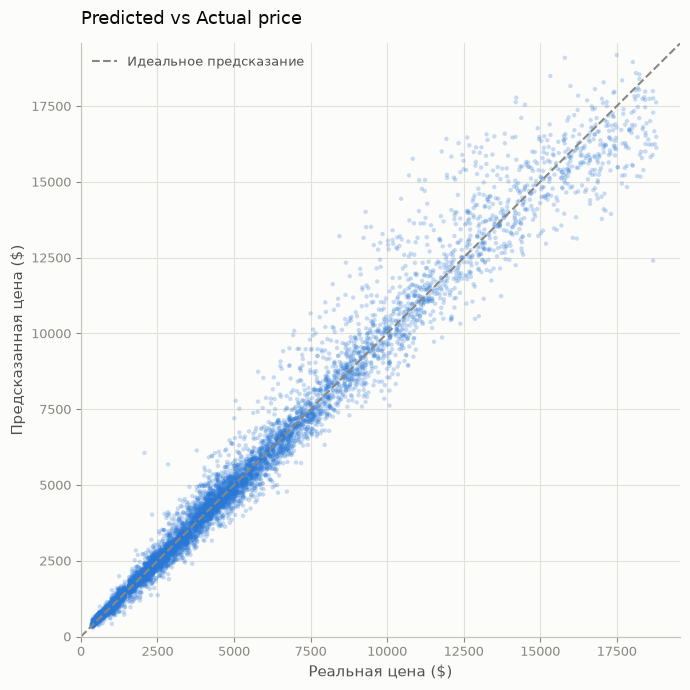

In [8]:
INK, SECONDARY, MUTED, GRID, SURFACE = '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#fcfcfb'

fig, ax = plt.subplots(figsize=(7, 7), facecolor=SURFACE)
ax.set_facecolor(SURFACE)

ax.scatter(y_test_dollars, preds_dollars, s=10, c='#2a78d6', alpha=0.25, edgecolors='none')

lims = [0, max(y_test_dollars.max(), preds_dollars.max()) * 1.02]
ax.plot(lims, lims, color=MUTED, linewidth=1.5, linestyle='--', label='Идеальное предсказание')

ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel('Реальная цена ($)', color=SECONDARY, fontsize=11)
ax.set_ylabel('Предсказанная цена ($)', color=SECONDARY, fontsize=11)
ax.set_title('Predicted vs Actual price', color=INK, fontsize=13, pad=14, loc='left')

ax.grid(True, color=GRID, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_color('#c3c2b7')
ax.tick_params(colors=MUTED, labelsize=9)
ax.legend(frameon=False, fontsize=9, labelcolor=SECONDARY, loc='upper left')

plt.tight_layout()
plt.show()

In [9]:
# GridSearchCV для PyTorch-модели через skorch (обёртка, которая даёт nn.Module
# интерфейс sklearn-совместимой модели: .fit()/.predict(), совместимость с GridSearchCV)
# !pip install skorch  — если библиотека ещё не установлена
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, make_scorer
from skorch import NeuralNetRegressor

X_gs = df_diamonds[feature_cols].values
y_gs = df_diamonds['price'].values.reshape(-1, 1)
X_train_gs, X_test_gs, y_train_gs, y_test_gs = train_test_split(X_gs, y_gs, test_size=0.2, random_state=42)

x_scaler_gs = StandardScaler()
X_train_gs = x_scaler_gs.fit_transform(X_train_gs).astype(np.float32)
X_test_gs = x_scaler_gs.transform(X_test_gs).astype(np.float32)
y_scaler_gs = StandardScaler()
y_train_gs = y_scaler_gs.fit_transform(y_train_gs).astype(np.float32)
y_test_gs = y_scaler_gs.transform(y_test_gs).astype(np.float32)


class GridRegressor(nn.Module):
    def __init__(self, n_features=9, hidden1=32, hidden2=32):
        super().__init__()
        self.fc1 = nn.Linear(n_features, hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.fc3 = nn.Linear(hidden2, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        return self.fc3(x)


net = NeuralNetRegressor(
    GridRegressor,
    module__n_features=len(feature_cols),
    criterion=nn.L1Loss,
    optimizer=torch.optim.Adam,
    max_epochs=20,
    batch_size=64,
    verbose=0,
    train_split=None,  # GridSearchCV уже делает CV-разбиение, внутренний split не нужен
)

# сетка небольшая для скорости — можно расширить (добавить lr, batch_size и т.д.)
param_grid = {
    'module__hidden1': [32, 64],
    'module__hidden2': [32, 64],
    'lr': [1e-3, 5e-4],
}

scorer = make_scorer(mean_absolute_error, greater_is_better=False)

grid = GridSearchCV(net, param_grid, scoring=scorer, cv=3, n_jobs=1, verbose=2)
grid.fit(X_train_gs, y_train_gs)

print("\nЛучшие параметры:", grid.best_params_)
print("Лучший CV score (neg MAE, scaled):", grid.best_score_)

best_model = grid.best_estimator_
preds_scaled_gs = best_model.predict(X_test_gs)
preds_dollars_gs = y_scaler_gs.inverse_transform(preds_scaled_gs)
y_test_dollars_gs = y_scaler_gs.inverse_transform(y_test_gs)
mae_gs = mean_absolute_error(y_test_dollars_gs, preds_dollars_gs)
print(f"Test MAE (доллары): ${mae_gs:.2f}")

Fitting 3 folds for each of 8 candidates, totalling 24 fits
[CV] END ...lr=0.001, module__hidden1=32, module__hidden2=32; total time=   3.6s
[CV] END ...lr=0.001, module__hidden1=32, module__hidden2=32; total time=   3.7s
[CV] END ...lr=0.001, module__hidden1=32, module__hidden2=32; total time=   3.7s
[CV] END ...lr=0.001, module__hidden1=32, module__hidden2=64; total time=   3.6s
[CV] END ...lr=0.001, module__hidden1=32, module__hidden2=64; total time=   3.6s
[CV] END ...lr=0.001, module__hidden1=32, module__hidden2=64; total time=   3.7s
[CV] END ...lr=0.001, module__hidden1=64, module__hidden2=32; total time=   3.6s
[CV] END ...lr=0.001, module__hidden1=64, module__hidden2=32; total time=   3.6s
[CV] END ...lr=0.001, module__hidden1=64, module__hidden2=32; total time=   3.6s
[CV] END ...lr=0.001, module__hidden1=64, module__hidden2=64; total time=   3.8s
[CV] END ...lr=0.001, module__hidden1=64, module__hidden2=64; total time=   3.8s
[CV] END ...lr=0.001, module__hidden1=64, module_

In [10]:
# Optuna — альтернатива GridSearch: вместо перебора всех комбинаций сетки,
# выбирает следующую точку на основе результатов предыдущих (байесовская оптимизация).
# Обычно находит хорошие гиперпараметры за меньшее число попыток, чем полный grid.
# !pip install optuna optuna-dashboard  — если библиотеки ещё не установлены
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# отдельная валидационная выборка из train — test трогаем только один раз, в самом конце
X_tr_opt, X_val_opt, y_tr_opt, y_val_opt = train_test_split(
    X_train_gs, y_train_gs, test_size=0.2, random_state=42
)


def objective(trial):
    hidden1 = trial.suggest_categorical('hidden1', [16, 32, 64, 128])
    hidden2 = trial.suggest_categorical('hidden2', [16, 32, 64, 128])
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])

    torch.manual_seed(42)
    trial_model = GridRegressor(n_features=len(feature_cols), hidden1=hidden1, hidden2=hidden2)
    loss_fn = nn.L1Loss()
    optimizer = torch.optim.Adam(trial_model.parameters(), lr=lr)
    loader = DataLoader(DiamondsDataset(X_tr_opt, y_tr_opt), batch_size=batch_size, shuffle=True)

    for epoch in range(15):
        trial_model.train()
        for xb, yb in loader:
            optimizer.zero_grad()
            loss = loss_fn(trial_model(xb), yb)
            loss.backward()
            optimizer.step()

    trial_model.eval()
    with torch.no_grad():
        val_preds = trial_model(torch.from_numpy(X_val_opt)).numpy()
    return mean_absolute_error(y_val_opt, val_preds)  # в масштабированных единицах — быстрее для перебора


# storage=SQLite-файл — сохраняет все trials на диск, чтобы optuna-dashboard мог их прочитать
# (без storage study живёт только в памяти процесса и исчезает вместе с ядром ноутбука)
study = optuna.create_study(
    study_name='diamonds-price-regressor',
    storage='sqlite:///optuna_diamonds.db',
    load_if_exists=True,
    direction='minimize',
)
study.optimize(objective, n_trials=25)

print("Лучшие параметры:", study.best_params)
print("Лучший val MAE (scaled):", study.best_value)

# финальная модель на лучших параметрах: обучаем на всём train, оцениваем один раз на test
best = study.best_params
torch.manual_seed(42)
final_model = GridRegressor(n_features=len(feature_cols), hidden1=best['hidden1'], hidden2=best['hidden2'])
loss_fn = nn.L1Loss()
optimizer = torch.optim.Adam(final_model.parameters(), lr=best['lr'])
loader = DataLoader(DiamondsDataset(X_train_gs, y_train_gs), batch_size=best['batch_size'], shuffle=True)
for epoch in range(30):
    final_model.train()
    for xb, yb in loader:
        optimizer.zero_grad()
        loss = loss_fn(final_model(xb), yb)
        loss.backward()
        optimizer.step()

final_model.eval()
with torch.no_grad():
    test_preds_scaled = final_model(torch.from_numpy(X_test_gs)).numpy()
test_preds_dollars = y_scaler_gs.inverse_transform(test_preds_scaled)
y_test_dollars_opt = y_scaler_gs.inverse_transform(y_test_gs)
mae_opt = mean_absolute_error(y_test_dollars_opt, test_preds_dollars)
print(f"\nTest MAE (доллары): ${mae_opt:.2f}")

/Users/dashanalivayko/Library/Python/3.11/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Лучшие параметры: {'hidden1': 32, 'hidden2': 64, 'lr': 0.0015415392443445454, 'batch_size': 32}
Лучший val MAE (scaled): 0.07434171438217163

Test MAE (доллары): $288.50


## Дашборд Optuna

После того как ячейка выше отработала (файл `optuna_diamonds.db` появился в этой же папке), открой **отдельный терминал** (не в ноутбуке — дашборд запускает веб-сервер, который блокирует ячейку, пока работает) и выполни:

```bash
optuna-dashboard sqlite:///optuna_diamonds.db
```

Если команда `optuna-dashboard` не находится (не в PATH), используй полный путь:

```bash
~/Library/Python/3.11/bin/optuna-dashboard sqlite:///optuna_diamonds.db
```

Дашборд поднимется на `http://127.0.0.1:8080` — открой эту ссылку в браузере. Там будут интерактивные графики:
- **History** — как менялась ошибка (val MAE) от попытки к попытке
- **Parameter importances** — какой гиперпараметр сильнее всего влияет на результат
- **Parallel coordinate / slice** — как разные значения `hidden1`, `hidden2`, `lr`, `batch_size` соотносятся с качеством

Дашборд обновляется в реальном времени — если снова запустишь ячейку с `study.optimize(...)` (например, с большим `n_trials`), новые trials появятся на дашборде без перезапуска сервера, так как оба процесса читают/пишут в один и тот же `optuna_diamonds.db`.

In [15]:
from torch.utils.tensorboard import SummaryWriter
import datetime

# Сравнение видов нормализации внутри сети (BatchNorm, LayerNorm), объединённых с Dropout,
# плюс early stopping. Все три техники решают разные проблемы и комбинируются свободно:
#   - BatchNorm1d / LayerNorm — стабилизируют распределение активаций между слоями
#     (BatchNorm — статистика по батчу, LayerNorm — по признакам одного примера)
#   - Dropout                 — на каждом шаге случайно зануляет часть нейронов,
#                               не даёт слоям "заучивать" друг друга (снижает переобучение)
#   - Early stopping          — следит за test_loss по эпохам и останавливает обучение,
#                               если он не улучшается patience эпох подряд
# Порядок в forward: Linear → Norm → ReLU → Dropout — сначала стабилизируем распределение,
# потом активация, потом зануляем часть нейронов
#
# InstanceNorm1d сюда сознательно не включена: она создана для данных с осью
# "канал x длина" (аудио/временные ряды/изображения) и требует length > 1, чтобы
# посчитать дисперсию внутри канала. У табличных фичей такой оси нет — один пример
# либо разворачивается в 1 канал длины n_features (тогда PyTorch требует num_features
# при создании слоя совпадать с числом каналов, а не с длиной — не подходит),
# либо в n_features каналов длины 1 (дисперсию по одному числу считать нечем —
# PyTorch явно кидает ValueError: "Expected more than 1 spatial element").
# Оба варианта проверялись и упираются в архитектурное ограничение слоя, а не в баг кода.
class NormRegressor(nn.Module):
    def __init__(self, n_features, hidden1=64, hidden2=64, norm_type='batch', dropout=0.2):
        super().__init__()
        self.fc1 = nn.Linear(n_features, hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.fc3 = nn.Linear(hidden2, 1)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

        def make_norm(n):
            if norm_type == 'batch':
                return nn.BatchNorm1d(n)
            elif norm_type == 'layer':
                return nn.LayerNorm(n)
            raise ValueError(f"unknown norm_type: {norm_type}")

        self.norm1 = make_norm(hidden1)
        self.norm2 = make_norm(hidden2)

    def forward(self, x):
        x = self.dropout(self.relu(self.norm1(self.fc1(x))))
        x = self.dropout(self.relu(self.norm2(self.fc2(x))))
        return self.fc3(x)


def train_with_norm(norm_type, dropout=0.2, n_epochs=45, patience=5):
    best = study.best_params
    torch.manual_seed(42)
    net = NormRegressor(
        n_features=len(feature_cols), hidden1=best['hidden1'], hidden2=best['hidden2'],
        norm_type=norm_type, dropout=dropout,
    )
    loss_fn = nn.L1Loss()
    optimizer = torch.optim.Adam(net.parameters(), lr=best['lr'])
    train_loader_n = DataLoader(DiamondsDataset(X_train_gs, y_train_gs), batch_size=best['batch_size'], shuffle=True)
    test_loader_n = DataLoader(DiamondsDataset(X_test_gs, y_test_gs), batch_size=best['batch_size'], shuffle=False)

    run_name = f"norm_{norm_type}_do{dropout}_{datetime.datetime.now():%Y%m%d_%H%M%S}"
    writer = SummaryWriter(log_dir=f"runs/{run_name}")

    best_test_loss = float('inf')
    best_state = None
    epochs_without_improvement = 0
    stopped_epoch = n_epochs

    for epoch in range(n_epochs):
        net.train()
        train_loss = 0.0
        for X_batch, y_batch in train_loader_n:
            optimizer.zero_grad()
            loss = loss_fn(net(X_batch), y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * len(X_batch)
        train_loss /= len(train_loader_n.dataset)

        net.eval()  # выключает BatchNorm running stats и Dropout на валидации/инференсе
        test_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in test_loader_n:
                test_loss += loss_fn(net(X_batch), y_batch).item() * len(X_batch)
        test_loss /= len(test_loader_n.dataset)

        writer.add_scalars('MAE (scaled)', {'train': train_loss, 'test': test_loss}, epoch)

        if test_loss < best_test_loss:
            best_test_loss = test_loss
            best_state = {k: v.clone() for k, v in net.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                stopped_epoch = epoch + 1
                break

    # откатываемся к весам лучшей (не последней) эпохи — иначе early stopping
    # не даёт эффекта: последние patience эпох модель уже переобучалась
    net.load_state_dict(best_state)

    net.eval()
    with torch.no_grad():
        preds_scaled = net(torch.from_numpy(X_test_gs)).numpy()
    preds_dollars = y_scaler_gs.inverse_transform(preds_scaled)
    y_test_dollars = y_scaler_gs.inverse_transform(y_test_gs)

    mae = mean_absolute_error(y_test_dollars, preds_dollars)
    rmse = root_mean_squared_error(y_test_dollars, preds_dollars)
    mape = mean_absolute_percentage_error(y_test_dollars, preds_dollars) * 100

    writer.add_hparams(
        {'hidden1': best['hidden1'], 'hidden2': best['hidden2'], 'lr': best['lr'],
         'batch_size': best['batch_size'], 'norm_type': norm_type, 'dropout': dropout,
         'stopped_epoch': stopped_epoch},
        {'hparam/MAE_dollars': mae, 'hparam/RMSE_dollars': rmse, 'hparam/MAPE_pct': mape},
    )
    writer.close()
    print(f"{norm_type}: остановлено на эпохе {stopped_epoch}/{n_epochs} (best test MAE scaled: {best_test_loss:.4f})")
    return {'norm_type': norm_type, 'mae': mae, 'rmse': rmse, 'mape': mape, 'stopped_epoch': stopped_epoch}


results = [train_with_norm(norm_type) for norm_type in ['batch', 'layer']]

print(f"\n{'norm_type':<10} {'MAE ($)':>10} {'RMSE ($)':>10} {'MAPE (%)':>10} {'epoch':>8}")
for r in results:
    print(f"{r['norm_type']:<10} {r['mae']:>10.2f} {r['rmse']:>10.2f} {r['mape']:>10.2f} {r['stopped_epoch']:>8}")

print(f"\nЗапусти в отдельном терминале: tensorboard --logdir runs")

batch: остановлено на эпохе 6/45 (best test MAE scaled: 0.1040)
layer: остановлено на эпохе 25/45 (best test MAE scaled: 0.0823)

norm_type     MAE ($)   RMSE ($)   MAPE (%)    epoch
batch          415.96     815.79      13.34        6
layer          329.30     629.53      10.97       25

Запусти в отдельном терминале: tensorboard --logdir runs


In [ ]:
# Упаковка в sklearn Pipeline: OrdinalEncoder + StandardScaler → PyTorch-модель (NormRegressor),
# без skorch/GridSearchCV — модель оборачивается вручную в свой fit/predict, совместимый
# с sklearn API (BaseEstimator, RegressorMixin), а таргет (price) масштабируется отдельно
# через TransformedTargetRegressor, чтобы pipeline.predict() сразу возвращал доллары
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline


class TorchNormRegressor(BaseEstimator, RegressorMixin):
    def __init__(self, hidden1=32, hidden2=64, lr=1e-3, batch_size=32,
                 norm_type='layer', dropout=0.0, n_epochs=45, patience=5,
                 val_size=0.1, random_state=42, log_tensorboard=True):
        self.hidden1 = hidden1
        self.hidden2 = hidden2
        self.lr = lr
        self.batch_size = batch_size
        self.norm_type = norm_type
        self.dropout = dropout
        self.n_epochs = n_epochs
        self.patience = patience
        self.val_size = val_size
        self.random_state = random_state
        self.log_tensorboard = log_tensorboard

    def fit(self, X, y):
        X = np.asarray(X, dtype=np.float32)
        y = np.asarray(y, dtype=np.float32).reshape(-1, 1)

        # внутренний train/val split — чтобы early stopping не подглядывал в тот test,
        # на котором потом будет оцениваться весь pipeline. val_size=0.1 (не 0.2), чтобы
        # модель обучалась на 90% train (72% всех данных), а не на 64%, как было раньше
        X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=self.val_size, random_state=self.random_state)

        torch.manual_seed(self.random_state)
        self.model_ = NormRegressor(
            n_features=X.shape[1], hidden1=self.hidden1, hidden2=self.hidden2,
            norm_type=self.norm_type, dropout=self.dropout,
        )
        loss_fn = nn.L1Loss()
        optimizer = torch.optim.Adam(self.model_.parameters(), lr=self.lr)
        train_loader = DataLoader(DiamondsDataset(X_tr, y_tr), batch_size=self.batch_size, shuffle=True)
        val_loader = DataLoader(DiamondsDataset(X_val, y_val), batch_size=self.batch_size, shuffle=False)

        writer = None
        if self.log_tensorboard:
            run_name = f"pipeline_{self.norm_type}_do{self.dropout}_{datetime.datetime.now():%Y%m%d_%H%M%S}"
            writer = SummaryWriter(log_dir=f"runs/{run_name}")

        best_val_loss = float('inf')
        best_state = None
        epochs_without_improvement = 0

        for epoch in range(self.n_epochs):
            self.model_.train()
            train_loss = 0.0
            for X_batch, y_batch in train_loader:
                optimizer.zero_grad()
                loss = loss_fn(self.model_(X_batch), y_batch)
                loss.backward()
                optimizer.step()
                train_loss += loss.item() * len(X_batch)
            train_loss /= len(train_loader.dataset)

            self.model_.eval()
            val_loss = 0.0
            with torch.no_grad():
                for X_batch, y_batch in val_loader:
                    val_loss += loss_fn(self.model_(X_batch), y_batch).item() * len(X_batch)
            val_loss /= len(val_loader.dataset)

            if writer is not None:
                writer.add_scalars('MAE (scaled)', {'train': train_loss, 'val': val_loss}, epoch)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_state = {k: v.clone() for k, v in self.model_.state_dict().items()}
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1
                if epochs_without_improvement >= self.patience:
                    break

        if writer is not None:
            writer.close()

        self.model_.load_state_dict(best_state)
        self.model_.eval()
        return self

    def predict(self, X):
        X = np.asarray(X, dtype=np.float32)
        with torch.no_grad():
            preds = self.model_(torch.from_numpy(X)).numpy()
        return preds.reshape(-1)


categorical_cols = ['cut', 'color', 'clarity']
numeric_cols = ['carat', 'depth', 'table', 'x', 'y', 'z']

preprocessor = ColumnTransformer([
    ('cat', OrdinalEncoder(categories=[cut_order, color_order, clarity_order]), categorical_cols),
    ('num', StandardScaler(), numeric_cols),
])

best = study.best_params
regressor = TransformedTargetRegressor(
    regressor=TorchNormRegressor(
        hidden1=best['hidden1'], hidden2=best['hidden2'], lr=best['lr'], batch_size=best['batch_size'],
        norm_type='layer', dropout=0.0,  # лучшая конфигурация из экспериментов выше: LayerNorm без Dropout
    ),
    transformer=StandardScaler(),
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', regressor),
])

# исходный (не предобработанный вручную) датафрейм — колонки ещё строковые ('Fair'/'D'/'IF' и т.д.),
# весь encoding/scaling теперь делает сам pipeline
df_raw = pd.read_csv('./diamonds.csv')
n_zero_dims_raw = (df_raw[['x', 'y', 'z']] == 0).sum(axis=1)
df_raw = df_raw[~(n_zero_dims_raw >= 2)].reset_index(drop=True)
z_missing_raw = df_raw['z'] == 0
df_raw.loc[z_missing_raw, 'z'] = (
    df_raw.loc[z_missing_raw, 'depth'] / 100 * (df_raw.loc[z_missing_raw, 'x'] + df_raw.loc[z_missing_raw, 'y']) / 2
)

X_raw = df_raw[categorical_cols + numeric_cols]
y_raw = df_raw['price'].values

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(X_raw, y_raw, test_size=0.2, random_state=42)

pipeline.fit(X_train_raw, y_train_raw)
preds_pipeline = pipeline.predict(X_test_raw)

mae_pipeline = mean_absolute_error(y_test_raw, preds_pipeline)
rmse_pipeline = root_mean_squared_error(y_test_raw, preds_pipeline)
mape_pipeline = mean_absolute_percentage_error(y_test_raw, preds_pipeline) * 100

print(f"MAE:  ${mae_pipeline:.2f}")
print(f"RMSE: ${rmse_pipeline:.2f}")
print(f"MAPE: {mape_pipeline:.2f}%")
print(f"\nЗапусти в отдельном терминале: tensorboard --logdir runs")